In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # 반드시 가장 먼저 실행!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore') # 혹시 모를 다른 자잘한 경고도 숨김

from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# ==========================================
# 0. 윈도우 환경 한글 폰트 및 시각화 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 및 기존 TF-IDF 파일 로드
# ==========================================
print("데이터 및 모델을 로드하는 중...")
comments_df = pd.read_csv('preprocessed_comments.csv', encoding='utf-8-sig')
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# README.md에 명시된 전처리 결과물 로드
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# TF-IDF 단어 인덱스 사전 (빠른 가중치 매칭용)
tfidf_vocab = vectorizer.vocabulary_
tfidf_dense = tfidf_matrix.toarray()  # (197, 5000) 밀집 행렬로 변환

# ==========================================
# 2. Word2Vec 모델 학습
# ==========================================
print("Word2Vec 모델 학습 중...")
comments_df['tokens_list'] = comments_df['tokens_clean'].fillna('').apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=comments_df['tokens_list'], 
                     vector_size=100, window=5, min_count=2, workers=4)

# ==========================================
# 3. TF-IDF 가중치를 적용한 영상 벡터화 (Weighted Average)
# ==========================================
def get_weighted_vector(tokens_str, w2v_model, tfidf_vec=None):
    """
    Word2Vec 벡터에 TF-IDF 가중치를 곱하여 가중 평균 벡터를 반환
    """
    words = str(tokens_str).split()
    valid_words = [word for word in words if word in w2v_model.wv]
    
    if not valid_words:
        return np.zeros(w2v_model.vector_size)
        
    vectors = []
    weights = []
    
    for word in valid_words:
        vectors.append(w2v_model.wv[word])
        
        # 단어의 TF-IDF 가중치 추출
        weight = 1.0  # 기본 가중치
        if tfidf_vec is not None and word in tfidf_vocab:
            word_idx = tfidf_vocab[word]
            weight = tfidf_vec[word_idx]
            # 5000개 단어장에 있지만 현재 문서에서 비중이 낮아 0인 경우 최소치 부여
            if weight == 0:
                weight = 0.01 
                
        weights.append(weight)
        
    vectors = np.array(vectors)
    weights = np.array(weights).reshape(-1, 1) # 브로드캐스팅을 위해 형태 변환
    
    # 가중 평균 계산: (벡터 * 가중치)의 합 / 가중치의 합
    weighted_avg = np.sum(vectors * weights, axis=0) / np.sum(weights)
    return weighted_avg

# ==========================================
# 3. TF-IDF 가중치를 적용한 영상 벡터화 (Weighted Average)
# ==========================================
# (이전 함수 get_weighted_vector 등은 그대로 유지)

print("197개 영상별 TF-IDF 가중 평균 벡터 생성 중...")
video_vectors = []
for i, row in video_df.iterrows():
    tokens = row['all_tokens']
    tfidf_vec = tfidf_dense[i]  
    vec = get_weighted_vector(tokens, w2v_model, tfidf_vec)
    video_vectors.append(vec)
    
video_vectors = np.vstack(video_vectors)

# [추가된 핵심 코드] 벡터 영점 조절 (Mean Centering)
# 모든 영상 벡터의 중심(평균)을 구해서 빼줌으로써 0.999 뭉침 현상 해결
global_mean = np.mean(video_vectors, axis=0)
video_vectors_centered = video_vectors - global_mean

video_vectors_normalized = normalize(video_vectors_centered, norm='l2')

# ==========================================
# 4. 추천 로직 (Global Search 코사인 유사도) - L2 정규화 반영
# ==========================================
def recommend_by_weighted_w2v(keywords, top_n=5):
    query_tfidf = vectorizer.transform([keywords]).toarray()[0]
    query_vec = get_weighted_vector(keywords, w2v_model, query_tfidf).reshape(1, -1)
    
    if np.all(query_vec == 0):
        print(f"'{keywords}'에 포함된 단어들이 학습 데이터(댓글)에 존재하지 않습니다.")
        return

    # 1. 쿼리 벡터에도 똑같이 중심(global_mean)을 빼줌
    query_vec_centered = query_vec - global_mean
    
    # 2. [추가된 부분] 쿼리 벡터도 L2 정규화 적용 (길이를 1로 맞춤)
    query_vec_normalized = normalize(query_vec_centered, norm='l2')

    # 3. [수정된 부분] 영점 조절 및 정규화가 완료된 벡터들끼리 유사도 계산
    # (주의: video_vectors_centered 가 아니라 video_vectors_normalized 로 변경됨)
    similarities = cosine_similarity(query_vec_normalized, video_vectors_normalized).flatten()
    sorted_indices = similarities.argsort()[::-1][:top_n]

    print(f'🔍 검색 키워드: "{keywords}"')
    print("=" * 60)
    
    for rank, idx in enumerate(sorted_indices, 1):
        row = video_df.iloc[idx]
        sim = similarities[idx]
        print(f'{rank}. [{row["category"]}] {row["Video Title"]}')
        # 유사도를 소수점 4자리까지 표시
        print(f'   점수(유사도): {sim:.4f} | 좋아요: {row["Likes"]:,} | 댓글 수: {row["comment_count"]}건')
        print(f'   URL: {row["Video URL"]}\n')

# ==========================================
# 5. 실행 테스트
# ==========================================
recommend_by_weighted_w2v('감동 응원 열정', top_n=5)
recommend_by_weighted_w2v('전쟁 평화 국제', top_n=3)

데이터 및 모델을 로드하는 중...
Word2Vec 모델 학습 중...
197개 영상별 TF-IDF 가중 평균 벡터 생성 중...
🔍 검색 키워드: "감동 응원 열정"
1. [월드컵] 드라마도 이렇게는 못 쓴다...😂 경우의 수보다 중요한 건 '꺾이지 않는 마음' [카타르월드컵 H조 대한민국 vs 포르투갈]
   점수(유사도): 0.9919 | 좋아요: 28,975 | 댓글 수: 50건
   URL: https://www.youtube.com/watch?v=2iaiuOQM458&pp=ygUJ7JuU65Oc7Lu1

2. [월드컵] [2026 FIFA 북중미 월드컵 아시아 3차 예선] 이라크 vs 대한민국 풀 하이라이트
   점수(유사도): 0.9918 | 좋아요: 30,616 | 댓글 수: 48건
   URL: https://www.youtube.com/watch?v=uw_X4usDCWE&pp=ygUJ7JuU65Oc7Lu1

3. [뉴진스] [뮤뱅 원테이크 4K] 뉴진스(NewJeans) 'Attention' 4K Bonus Ver. @뮤직뱅크(Music Bank) 220805
   점수(유사도): 0.9902 | 좋아요: 439,196 | 댓글 수: 50건
   URL: https://www.youtube.com/watch?v=CHp0Kaidr14&list=RDCHp0Kaidr14&start_radio=1&pp=ygUJ64m07KeE7IqkoAcB

4. [월드컵] [축구국가대표팀 친선경기] 대한민국 vs 코트디부아르 풀 하이라이트
   점수(유사도): 0.9899 | 좋아요: 8,966 | 댓글 수: 50건
   URL: https://www.youtube.com/watch?v=gRs41rOPvx8&pp=ygUJ7JuU65Oc7Lu1

5. [인공지능] "10년도 안 남았다." 앞으로 세상을 지배할 충격적인 기술ㅣ지식인초대석 EP.68 (김대식 교수 1부)
   점수(유사도): 0.9888 | 좋아요: 59,061 | 댓글 수: 49건
   URL: htt

K-Means 클러스터링 및 최적 k 탐색 중...

=== 클러스터별 대표 키워드 (TF-IDF 실제 의미 기반) ===
클러스터 0: 보다, 월드컵, newjeans, 아니다, 좋다, 뉴진스, 사람, 오다, ai, 나오다
클러스터 1: ai, 보다, 전쟁, 이스라엘, 교수, 이란, 뉴진스, 인간, 좋다, 감사하다
클러스터 2: newjeans, new, jean, never, miss, die, song, 뉴진스, danielle, back
클러스터 3: 이스라엘, 이란, 미국, 트럼프, 전쟁, 보다, 자유, 좋다, 히딩크, 노래

PCA 시각화 생성 중...


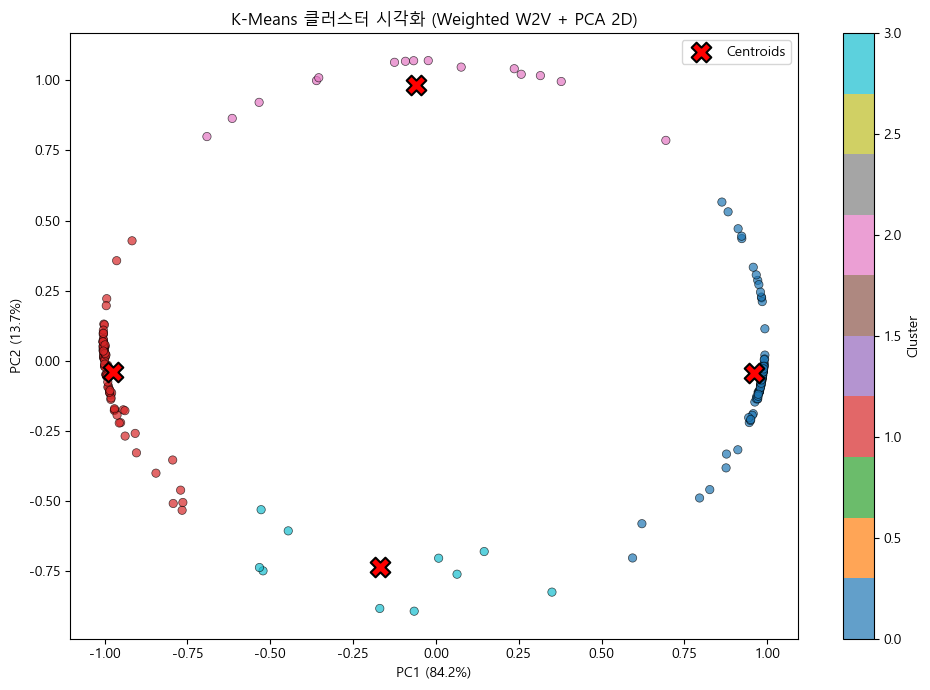


=== 카테고리 × 클러스터 교차표 ===
cluster    0   1   2   3  All
category                     
뉴진스       20  13  15   2   50
월드컵       36  12   0   1   49
이스라엘      16  29   0   5   50
인공지능      16  30   0   2   48
All       88  84  15  10  197

=== 카테고리별 클러스터 비율 ===
cluster       0      1    2      3
category                          
뉴진스       0.400  0.260  0.3  0.040
월드컵       0.735  0.245  0.0  0.020
이스라엘      0.320  0.580  0.0  0.100
인공지능      0.333  0.625  0.0  0.042


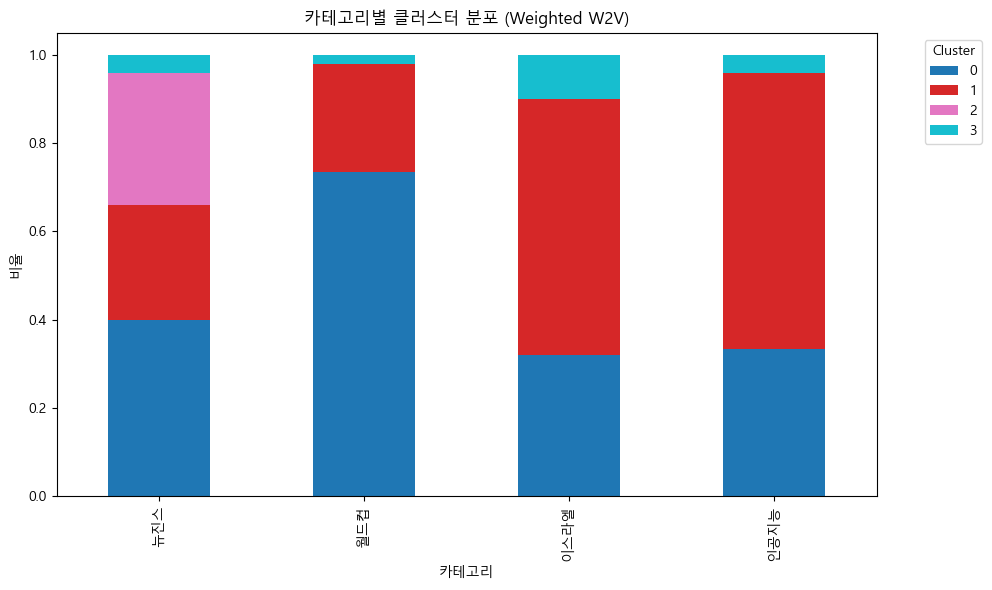

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# [기존 6번 대체] K-Means 모델 학습
# ==========================================
print("K-Means 클러스터링 및 최적 k 탐색 중...")

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # centered 대신 normalized 벡터 사용!
    km.fit(video_vectors_normalized) 
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(video_vectors_normalized, km.labels_))

best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(video_vectors_normalized) # 여기도 normalized 사용

video_df['cluster'] = kmeans.labels_

# ==========================================
# 7. 클러스터별 상위 키워드 추출 (TF-IDF 중요도 기반으로 변경)
# ==========================================
print("\n=== 클러스터별 대표 키워드 (TF-IDF 실제 의미 기반) ===")
feature_names = vectorizer.get_feature_names_out()

for i in range(best_k):
    # 1. 해당 클러스터에 속한 영상들의 인덱스 추출
    cluster_indices = np.where(kmeans.labels_ == i)[0]
    
    # 2. 해당 영상들의 원래 TF-IDF 벡터들만 가져오기
    cluster_tfidf = tfidf_dense[cluster_indices]
    
    # 3. 클러스터 내 영상들의 TF-IDF 평균 계산
    cluster_mean_tfidf = cluster_tfidf.mean(axis=0)
    
    # 4. 평균값이 가장 높은 단어 10개 추출
    top_indices = cluster_mean_tfidf.argsort()[::-1][:10]
    top_words = [feature_names[idx] for idx in top_indices]
    
    print(f'클러스터 {i}: {", ".join(top_words)}')

# ==========================================
# [기존 8번 대체] PCA 2D 시각화
# ==========================================
print("\nPCA 시각화 생성 중...")
pca = PCA(n_components=2, random_state=42)

# PCA에도 normalized 벡터를 입력하여 축소!
coords = pca.fit_transform(video_vectors_normalized)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=kmeans.labels_, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('K-Means 클러스터 시각화 (Weighted W2V + PCA 2D)')

# 클러스터 중심점 시각화
centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='k', linewidths=1.5, label='Centroids'
)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 9. 카테고리별 클러스터 분포 분석 (교차표)
# ==========================================
print("\n=== 카테고리 × 클러스터 교차표 ===")
cross = pd.crosstab(video_df['category'], video_df['cluster'], margins=True)
print(cross)

print('\n=== 카테고리별 클러스터 비율 ===')
cross_pct = pd.crosstab(video_df['category'], video_df['cluster'], normalize='index')
print(cross_pct.round(3))

# 시각화: 스택 바 차트
cross_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title('카테고리별 클러스터 분포 (Weighted W2V)')
plt.xlabel('카테고리')
plt.ylabel('비율')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()